<a href="https://colab.research.google.com/github/tahermatbouly/Credit-Card-Fraud-Detection/blob/main/Credit_Card_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Credit Card Fraud Detection**
##An AI tool that simulates an attack on a transaction then it detects and evaluate fraud and blocks it using classical ML and DL

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#**Dealing with the data and Doing some Presprocessing**

In [2]:
data = pd.read_csv("/content/paysim.csv")

In [3]:
data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110813 entries, 0 to 110812
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            110813 non-null  int64  
 1   type            110813 non-null  object 
 2   amount          110813 non-null  float64
 3   nameOrig        110813 non-null  object 
 4   oldbalanceOrg   110813 non-null  float64
 5   newbalanceOrig  110813 non-null  float64
 6   nameDest        110813 non-null  object 
 7   oldbalanceDest  110813 non-null  float64
 8   newbalanceDest  110812 non-null  float64
 9   isFraud         110812 non-null  float64
 10  isFlaggedFraud  110812 non-null  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 9.3+ MB


In [5]:
data.isna().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,1
isFraud,1


In [6]:
data["step"]

,step
0,1
1,1
2,1
3,1
4,1
...,...
110808,11
110809,11
110810,11
110811,11


In [7]:
data.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [8]:
data.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
110808,False
110809,False
110810,False
110811,False


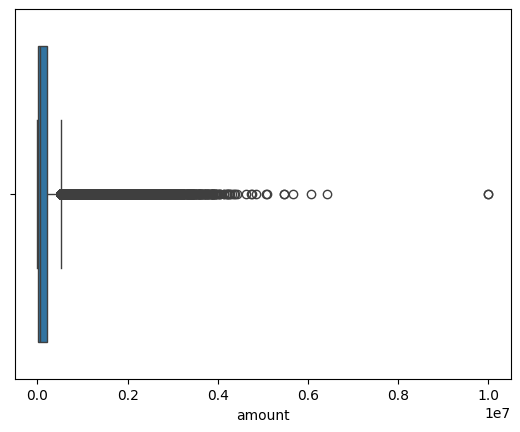

In [9]:
sns.boxplot(x=data['amount'])
plt.show()

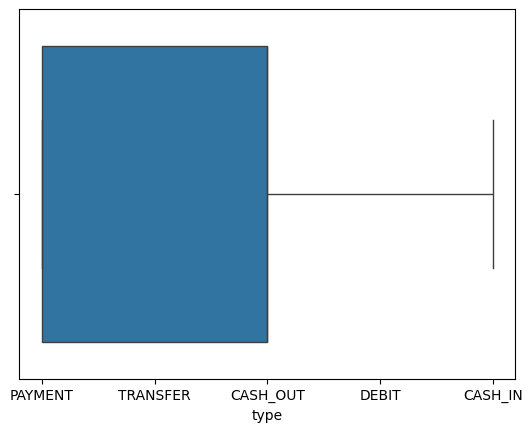

In [10]:
sns.boxplot(x=data['type'])
plt.show()

In [11]:
data['balance_diff_orig'] = data['newbalanceOrig'] - data['oldbalanceOrg']
data['balance_diff_dest'] = data['newbalanceDest'] - data['oldbalanceDest']

In [12]:
data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balance_diff_orig,balance_diff_dest
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0,-9839.64,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0,-1864.28,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0,-181.00,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0,-181.00,-21182.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0,-11668.14,0.0


In [13]:
data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balance_diff_orig,balance_diff_dest
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0,-9839.64,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0,-1864.28,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0,-181.00,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0,-181.00,-21182.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0,-11668.14,0.0


In [14]:
data = pd.get_dummies(data, columns=['type'], drop_first=True)

In [15]:
data.head()

,step,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balance_diff_orig,balance_diff_dest,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0,-9839.64,0.0,False,False,True,False
1,1,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0,-1864.28,0.0,False,False,True,False
2,1,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0,-181.00,0.0,False,False,False,True
3,1,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0,-181.00,-21182.0,True,False,False,False
4,1,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0,-11668.14,0.0,False,False,True,False


In [16]:
hour = data["step"] % 24
day = data["step"] // 24
is_night = (hour < 6)

In [17]:
data['amount'].mean()

np.float64(175905.06236181676)

In [18]:
data['is_high_amount'] = (data['amount'] > data['amount'].mean()).astype(int)

In [19]:
data["is_high_amount"]

,is_high_amount
0,0
1,0
2,0
3,0
4,0
...,...
110808,0
110809,0
110810,0
110811,1


In [20]:
data.head(30)

,step,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balance_diff_orig,balance_diff_dest,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,is_high_amount
0,1,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.0,0.00,0.0,0.0,-9839.64,0.00,False,False,True,False,0
1,1,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.0,0.00,0.0,0.0,-1864.28,0.00,False,False,True,False,0
2,1,181.00,C1305486145,181.00,0.00,C553264065,0.0,0.00,1.0,0.0,-181.00,0.00,False,False,False,True,0
3,1,181.00,C840083671,181.00,0.00,C38997010,21182.0,0.00,1.0,0.0,-181.00,-21182.00,True,False,False,False,0
4,1,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.0,0.00,0.0,0.0,-11668.14,0.00,False,False,True,False,0
5,1,7817.71,C90045638,53860.00,46042.29,M573487274,0.0,0.00,0.0,0.0,-7817.71,0.00,False,False,True,False,0
6,1,7107.77,C154988899,183195.00,176087.23,M408069119,0.0,0.00,0.0,0.0,-7107.77,0.00,False,False,True,False,0
7,1,7861.64,C1912850431,176087.23,168225.59,M633326333,0.0,0.00,0.0,0.0,-7861.64,0.00,False,False,True,False,0
8,1,4024.36,C1265012928,2671.00,0.00,M1176932104,0.0,0.00,0.0,0.0,-2671.00,0.00,False,False,True,False,0
9,1,5337.77,C712410124,41720.00,36382.23,C195600860,41898.0,40348.79,0.0,0.0,-5337.77,-1549.21,False,True,False,False,0


<Axes: xlabel='amount', ylabel='Count'>

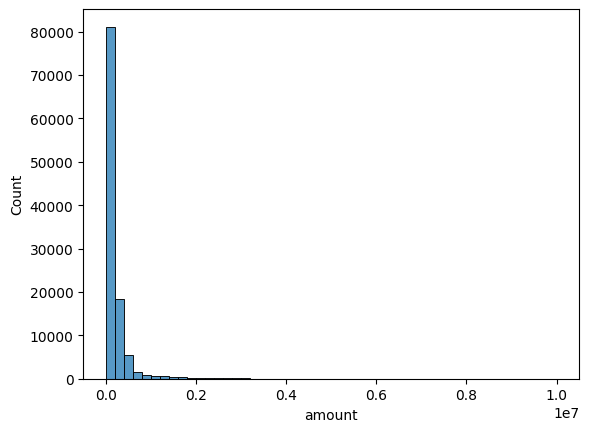

In [21]:
sns.histplot(data['amount'], bins=50)

#**Fraud is detected in high scaled data "amounts" , we are going to apply a normalization methid for the data which is Log Transformation**

In [22]:
data['amount_log'] = np.log1p(data['amount'])

In [23]:
data.head()

,step,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balance_diff_orig,balance_diff_dest,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,is_high_amount,amount_log
0,1,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0,-9839.64,0.0,False,False,True,False,0,9.194276
1,1,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0,-1864.28,0.0,False,False,True,False,0,7.531166
2,1,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0,-181.00,0.0,False,False,False,True,0,5.204007
3,1,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0,-181.00,-21182.0,True,False,False,False,0,5.204007
4,1,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0,-11668.14,0.0,False,False,True,False,0,9.364703


<Axes: xlabel='amount_log', ylabel='Count'>

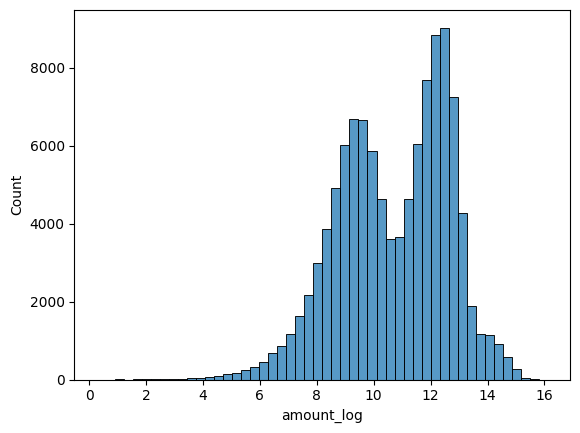

In [24]:
sns.histplot(data['amount_log'], bins=50)

#**Converting the categorical to int in the type columns**

In [25]:
data[['type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']] = \
data[['type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']].astype(int)

In [26]:
data.head()

,step,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balance_diff_orig,balance_diff_dest,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,is_high_amount,amount_log
0,1,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0,-9839.64,0.0,0,0,1,0,0,9.194276
1,1,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0,-1864.28,0.0,0,0,1,0,0,7.531166
2,1,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0,-181.00,0.0,0,0,0,1,0,5.204007
3,1,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0,-181.00,-21182.0,1,0,0,0,0,5.204007
4,1,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0,-11668.14,0.0,0,0,1,0,0,9.364703


In [27]:
data['error_orig'] = abs(
    data['oldbalanceOrg'] - data['newbalanceOrig'] - data['amount']
)

In [28]:
data['error_dest'] = abs(
    data['newbalanceDest'] - data['oldbalanceDest'] - data['amount']
)

In [30]:
data.head(20)

,step,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balance_diff_orig,balance_diff_dest,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,is_high_amount,amount_log,error_orig,error_dest
0,1,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.0,0.00,0.0,0.0,-9839.64,0.00,0,0,1,0,0,9.194276,1.455192e-11,9839.64
1,1,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.0,0.00,0.0,0.0,-1864.28,0.00,0,0,1,0,0,7.531166,1.136868e-12,1864.28
2,1,181.00,C1305486145,181.00,0.00,C553264065,0.0,0.00,1.0,0.0,-181.00,0.00,0,0,0,1,0,5.204007,0.000000e+00,181.00
3,1,181.00,C840083671,181.00,0.00,C38997010,21182.0,0.00,1.0,0.0,-181.00,-21182.00,1,0,0,0,0,5.204007,0.000000e+00,21363.00
4,1,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.0,0.00,0.0,0.0,-11668.14,0.00,0,0,1,0,0,9.364703,0.000000e+00,11668.14
5,1,7817.71,C90045638,53860.00,46042.29,M573487274,0.0,0.00,0.0,0.0,-7817.71,0.00,0,0,1,0,0,8.964275,9.094947e-13,7817.71
6,1,7107.77,C154988899,183195.00,176087.23,M408069119,0.0,0.00,0.0,0.0,-7107.77,0.00,0,0,1,0,0,8.869085,1.091394e-11,7107.77
7,1,7861.64,C1912850431,176087.23,168225.59,M633326333,0.0,0.00,0.0,0.0,-7861.64,0.00,0,0,1,0,0,8.969878,1.364242e-11,7861.64
8,1,4024.36,C1265012928,2671.00,0.00,M1176932104,0.0,0.00,0.0,0.0,-2671.00,0.00,0,0,1,0,0,8.300370,1.353360e+03,4024.36
9,1,5337.77,C712410124,41720.00,36382.23,C195600860,41898.0,40348.79,0.0,0.0,-5337.77,-1549.21,0,1,0,0,0,8.582751,3.637979e-12,6886.98


In [31]:
data['high_risk_transaction'] = (
    (data['type_TRANSFER'] == 1) &
    (data['is_high_amount'] == 1)
).astype(int)

In [32]:
data.head()

,step,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,...,balance_diff_dest,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,is_high_amount,amount_log,error_orig,error_dest,high_risk_transaction
0,1,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0,...,0.0,0,0,1,0,0,9.194276,1.455192e-11,9839.64,0
1,1,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0,...,0.0,0,0,1,0,0,7.531166,1.136868e-12,1864.28,0
2,1,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0,...,0.0,0,0,0,1,0,5.204007,0.000000e+00,181.00,0
3,1,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0,...,-21182.0,1,0,0,0,0,5.204007,0.000000e+00,21363.00,0
4,1,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0,...,0.0,0,0,1,0,0,9.364703,0.000000e+00,11668.14,0


In [33]:
data.drop(['nameOrig', 'nameDest'], axis=1, inplace=True)

In [34]:
data.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balance_diff_orig,balance_diff_dest,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,is_high_amount,amount_log,error_orig,error_dest,high_risk_transaction
0,1,9839.64,170136.0,160296.36,0.0,0.0,0.0,0.0,-9839.64,0.0,0,0,1,0,0,9.194276,1.455192e-11,9839.64,0
1,1,1864.28,21249.0,19384.72,0.0,0.0,0.0,0.0,-1864.28,0.0,0,0,1,0,0,7.531166,1.136868e-12,1864.28,0
2,1,181.00,181.0,0.00,0.0,0.0,1.0,0.0,-181.00,0.0,0,0,0,1,0,5.204007,0.000000e+00,181.00,0
3,1,181.00,181.0,0.00,21182.0,0.0,1.0,0.0,-181.00,-21182.0,1,0,0,0,0,5.204007,0.000000e+00,21363.00,0
4,1,11668.14,41554.0,29885.86,0.0,0.0,0.0,0.0,-11668.14,0.0,0,0,1,0,0,9.364703,0.000000e+00,11668.14,0


In [35]:
data.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balance_diff_orig,balance_diff_dest,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,is_high_amount,amount_log,error_orig,error_dest,high_risk_transaction
count,110813.000000,1.108130e+05,1.108130e+05,1.108130e+05,1.108130e+05,1.108120e+05,110812.000000,110812.0,1.108130e+05,1.108120e+05,110813.000000,110813.000000,110813.000000,110813.000000,110813.000000,110813.000000,1.108130e+05,1.108120e+05,110813.000000
mean,8.664958,1.759051e+05,8.941414e+05,9.101840e+05,8.871676e+05,1.186291e+06,0.001083,0.0,1.604255e+04,2.991243e+05,0.311823,0.009809,0.390884,0.085477,0.300660,10.690233,1.919476e+05,2.982846e+05,0.070154
std,1.809812,3.470360e+05,2.779029e+06,2.816472e+06,2.393870e+06,2.778425e+06,0.032890,0.0,1.358229e+05,9.710261e+05,0.463240,0.098555,0.487951,0.279592,0.458547,1.936548,3.557121e+05,8.232457e+05,0.255408
min,1.000000,3.200000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0,-1.000000e+07,-1.306083e+07,0.000000,0.000000,0.000000,0.000000,0.000000,0.277632,0.000000e+00,0.000000e+00,0.000000
25%,8.000000,1.023470e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0,-1.023807e+04,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,9.233637,1.000000e-02,5.715045e+03,0.000000
50%,9.000000,5.524493e+04,2.021200e+04,0.000000e+00,2.290103e+04,6.055630e+04,0.000000,0.0,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,10.919550,4.082920e+04,2.697401e+04,0.000000
75%,10.000000,2.145087e+05,1.985740e+05,2.239154e+05,6.103005e+05,1.083858e+06,0.000000,0.0,0.000000e+00,2.629659e+05,1.000000,0.000000,1.000000,0.000000,1.000000,12.276110,2.509042e+05,2.899320e+05,0.000000
max,11.000000,1.000000e+07,3.893942e+07,3.894623e+07,3.400874e+07,3.894623e+07,1.000000,0.0,1.289408e+06,3.889205e+07,1.000000,1.000000,1.000000,1.000000,1.000000,16.118096,6.388051e+06,3.514216e+07,1.000000


In [36]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110813 entries, 0 to 110812
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   step                   110813 non-null  int64  
 1   amount                 110813 non-null  float64
 2   oldbalanceOrg          110813 non-null  float64
 3   newbalanceOrig         110813 non-null  float64
 4   oldbalanceDest         110813 non-null  float64
 5   newbalanceDest         110812 non-null  float64
 6   isFraud                110812 non-null  float64
 7   isFlaggedFraud         110812 non-null  float64
 8   balance_diff_orig      110813 non-null  float64
 9   balance_diff_dest      110812 non-null  float64
 10  type_CASH_OUT          110813 non-null  int64  
 11  type_DEBIT             110813 non-null  int64  
 12  type_PAYMENT           110813 non-null  int64  
 13  type_TRANSFER          110813 non-null  int64  
 14  is_high_amount         110813 non-nu